## Implementing a GPT model from scratch to generate text
This chapter covers
* Coding a GPT-like large language model (LLM) 
that can be trained to generate human-like text

* Normalizing layer activations to stabilize neural 
network training

* Adding shortcut connections in deep neural 
networks 

* Implementing transformer blocks to create GPT 
models of various sizes

* Computing the number of parameters and 
storage requirements of GPT models

 Using GPT-2 Configuration, we will implement a GPT placeholder architecture (Dummy
GPTModel). This will provide us with a big-picture view of how
 everything fits together and what other components we need to code to assemble the
 full GPT model architecture.

In [1]:
#GPT-2 Configuration Dictionary
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": False        # Query-Key-Value bias
}

In [2]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x


 The DummyGPTModel class in this code defines a simplified version of a GPT-like
 model using PyTorch’s neural network module (nn.Module). The model architecture
 in the DummyGPTModel class consists of token and positional embeddings, dropout,
 a series of transformer blocks (DummyTransformerBlock), a final layer normalization
 (DummyLayerNorm), and a linear output layer (out_head). 
 
 The configuration is
 passed in via a Python dictionary, for instance, the GPT_CONFIG_124M dictionary we
 created earlier.

 The forward method describes the data flow through the model: it computes token
 and positional embeddings for the input indices, applies dropout, processes the data
 through the transformer blocks, applies normalization, and finally produces logits
 with the linear output layer.

 Next, we will prepare the input data and initialize a new GPT model to illustrate
 its usage. Building on our coding of the tokenizer (see chapter 2), let’s now con
sider a high-level overview of how data flows in and out of a GPT model

In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
print("Before Stacking:\n",batch)
batch = torch.stack(batch, dim = 0)

print("After Stacking:\n",batch)
print(batch.shape)

Before Stacking:
 [tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]
After Stacking:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4])


 Next, we initialize a new 124-million-parameter DummyGPTModel instance and feed it
 the tokenized batch.

  The output tensor has two rows corresponding to the two text samples. Each text sam
ple consists of four tokens; each token is a 50,257-dimensional vector, which matches
 the size of the tokenizer’s vocabulary.
 
 The embedding has 50,257 dimensions because each of these dimensions refers to
 a unique token in the vocabulary.

In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## Normalizing activations with layer normalization:
 Training deep neural networks with many layers can sometimes prove challenging
 due to problems like vanishing or exploding gradients.

  Let’s now implement layer normalization to improve the stability and efficiency of neu ral network training. The main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also
 known as unit variance. This adjustment speeds up the convergence to effective
 weights and ensures consistent, reliable training. 
 
 In GPT-2 and modern transformer
 architectures, layer normalization is typically applied before and after the multi-head
 attention module, and, as we have seen with the DummyLayerNorm placeholder, before
the final output layer. 

In [5]:
# Demonstrating the effect of layer normalization through a quick example
torch.manual_seed(123)
batch_example = torch.randn(2,5) #std distribution where mean = 0, variace = 1
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)


tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [6]:
# Examining Mean and Variance of the given layer
mean = out.mean(dim = -1, keepdim=True)
var = out.var(dim = -1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


 Next, let’s apply layer normalization to the layer outputs we obtained earlier.

In [7]:
out_norm = (out-mean)/torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [5.9605e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


Note that the value –5.9605e-08 in the output tensor is the scientific notation for–5.9605 × 10-8, which is –0.000000059605 in decimal form. This value is very close to 0,
 but it is not exactly 0 due to small numerical errors that can accumulate because of
 the finite precision with which computers represent numbers. 
To improve readability, we can also turn off the scientific notation when printing
 tensor values by setting sci_mode to False:

In [8]:
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


So far, we have coded and applied layer normalization in a step-by-step process. Let’s
 now encapsulate this process in a PyTorch module that we can use in the GPT model
 later.

In [9]:
# A layer normalization class
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))
    def forward(self,x):
        mean = x.mean(dim = -1, keepdim = True)
        var = x.var(dim = -1, keepdim = True, unbiased = False)
        norm_x = (x - mean)/(torch.sqrt(var + self.eps))
        return self.scale * norm_x + self.shift

Let’s now try the LayerNorm module in practice and apply it to the batch input:


In [10]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var) 

Mean:
 tensor([[    -0.0000],
        [     0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## Implementing a feed forward network with GELU activations
 Next, we will implement a small neural network submodule used as part of the trans
former block in LLMs. We begin by implementing the GELU activation function,
 which plays a crucial role in this neural network submodule. 

![GELU Activation Function](images/GELU.png)


In [11]:
# Implementing a GELU Class

class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

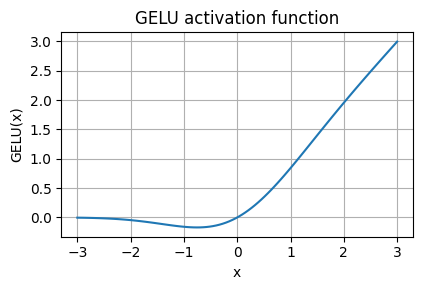

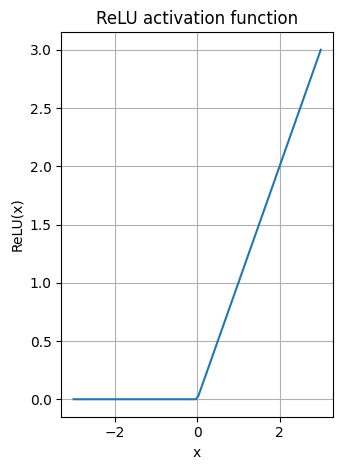

In [12]:
# Comparing GELU vs RELU 
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)    
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Next, let’s use the GELU function to implement the small neural network module,
 FeedForward, that we will be using in the LLM’s transformer block later.

Expanding to 4d

Now, instead of directly mapping 
768→768, we expand to 4*d

Now each 768-dim input vector gets mapped into a 3072-dim vector.

This bigger space allows the model to represent more combinations of features.

👉 Think of it like moving from a small room into a huge hall:
in the hall, you have more room to rearrange furniture (features).

In [13]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"] , 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])   
        )
    def forward(self, x):
        return self.layers(x)

 let’s initialize a new FeedForward module with a
 token embedding size of 768 and feed it a batch input with two samples and three
 tokens each:

In [14]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2,3,768)
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


## Adding shortcut connections

 Shortcut connections were proposed for deep networks in
 computer vision (specifically, in residual networks) to mitigate the challenge of van
ishing gradients. The vanishing gradient problem refers to the issue where gradients
 (which guide weight updates during training) become progressively smaller as they
 propagate backward through the layers, making it difficult to effectively train earlier
 layers.

A shortcut connection creates an alternative, shorter path
 for the gradient to flow through the network by skipping one or more layers, which is
 achieved by adding the output of one layer to the output of a later layer. This is why
 these connections are also known as skip connections. They play a crucial role in pre
serving the flow of gradients during the backward pass in training. 

In [15]:
# A neural network to demonstrate shortcut connections
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]), GELU())
        ])
        
    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

Let’s use this code to initialize a neural network without shortcut connections.
 Each layer will be initialized such that it accepts an example with three input values
 and returns three output values. The last layer returns a single output value:

In [16]:
layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)                           
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut=False
)

Next, we implement a function that computes the gradients in the model’s back
ward pass:

In [17]:
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)   
    loss.backward()
    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [18]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173590746708214
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152042235247791
layers.3.0.weight has gradient mean of 0.0013988739810883999
layers.4.0.weight has gradient mean of 0.00504964729771018


 Let’s now instantiate a model with skip connections and see how it compares:

In [19]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694102346897125
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


## Connecting attention and linear layers in a transformer block
 Now, let’s implement the transformer block, a fundamental building block of GPT and
 other LLM architectures. This block, which is repeated a dozen times in the 124-million
parameter GPT-2 architecture, combines several concepts we have previously covered:
 multi-head attention, layer normalization, dropout, feed forward layers, and GELU
 activations. Later, we will connect this transformer block to the remaining parts of the
 GPT architecture.

In [20]:
# The transformer block component

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias = False):
        super().__init__()
        assert(d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads #Projection dimension reduced to match output dimension
        self.W_query = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias = qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out) #Linear layer to combine outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask" , torch.triu(torch.ones(context_length, context_length), diagonal=1))
        
    def forward(self , x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        values = self.W_value(x)
        queries = self.W_query(x)
        
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
        
        keys = keys.transpose(1,2)
        values = values.transpose(1,2)
        queries = queries.transpose(1,2)
        
        attn_scores = queries @ keys.transpose(2,3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores/ keys.shape[-1] ** 0.5, dim = -1)    
        attn_weights = self.dropout(attn_weights)
        
        context_vec = (attn_weights @ values).transpose(1, 2)
        
        context_vec = context_vec.contiguous().view(b , num_tokens, self.d_out)
        
        context_vec = self.out_proj(context_vec) 
        return context_vec  
            
        
class TransformerBlock(nn.Module):
    def __init__(self , cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length = cfg["context_length"],
            num_heads = cfg["n_heads"],
            dropout = cfg["drop_rate"],
            qkv_bias = cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
        
    def forward(self , x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x
    

Using the GPT_CONFIG_124M dictionary we defined earlier, let’s instantiate a trans
former block and feed it some sample data:

In [21]:
torch.manual_seed(123)
x = torch.rand(2 , 4, 768)
block =  TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


 ## The GPT model architecture implementation

In [24]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"] , cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"] , cfg["vocab_size"] , bias = False)
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device = in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
        

Let’s now initialize the 124-million-parameter GPT model using the GPT_CONFIG_
 124M dictionary we pass into the cfg parameter and feed it with the batch text input
 we previously created:


In [25]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


Now  convert each of these 50,257
dimensional output vectors back into tokens.
Before we move on to coding the function that converts the model outputs into
 text, let’s spend a bit more time with the model architecture itself and analyze its size.
 Using the numel() method, short for “number of elements,” we can collect the total
 number of parameters in the model’s parameter tensors:

In [26]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


Why is the actual number of parameters 163 million? The reason is a concept called weight tying, which was used in the original GPT-2
 architecture. It means that the original GPT-2 architecture reuses the weights from
 the token embedding layer in its output layer. To understand better, let’s take a look at
 the shapes of the token embedding layer and linear output layer that we initialized on
 the model via the GPTModel earlier:


In [27]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


The token embedding and output layers are very large due to the number of rows for
 the 50,257 in the tokenizer’s vocabulary. Let’s remove the output layer parameter
 count from the total GPT-2 model count according to the weight tying:

In [29]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
 )
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


## Exercise 4.1 Number of parameters in feed forward and attention modules 
Calculate and compare the number of parameters that are contained in the feed forward module and those that are contained in the multi-head attention module.


In [ ]:
# GPT_CONFIG_124M = {
#     "vocab_size": 50257,
#     "context_length": 1024,
#     "emb_dim": 768,
#     "n_heads": 12,
#     "n_layers": 12,
#     "drop_rate": 0.1,
#     "qkv_bias": False
# }

# block = TransformerBlock(GPT_CONFIG_124M)
# print(block)

TransformerBlock(
  (att): MultiHeadAttention(
    (W_query): Linear(in_features=768, out_features=768, bias=False)
    (W_key): Linear(in_features=768, out_features=768, bias=False)
    (W_value): Linear(in_features=768, out_features=768, bias=False)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (ff): FeedForward(
    (layers): Sequential(
      (0): Linear(in_features=768, out_features=3072, bias=True)
      (1): GELU()
      (2): Linear(in_features=3072, out_features=768, bias=True)
    )
  )
  (norm1): LayerNorm()
  (norm2): LayerNorm()
  (drop_shortcut): Dropout(p=0.1, inplace=False)
)


In [ ]:
# total_params = sum(p.numel() for p in block.ff.parameters())
# print(f"Total number of parameters in feed forward module: {total_params:,}")

Total number of parameters in feed forward module: 4,722,432


In [33]:
total_params = sum(p.numel() for p in block.att.parameters())
print(f"Total number of parameters in attention module: {total_params * 12:,}")

Total number of parameters in attention module: 28,320,768


 let’s compute the memory requirements of the 163 million parameters in our
 GPTModel object:

In [34]:
#Assuming float32 4 bytes per parameters
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024)
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 9.00 MB
